In [3]:
import qutip as qt
import matplotlib.pyplot as plt
import numpy as np
import tqdm

# 3-1

## (a)

In [4]:
psi0 = qt.basis(2,0)
rho_init = psi0 * psi0.dag()

KAPPA = 1
J = qt.sigmax()

H = qt.qeye(2)

T = np.linspace(0, 5, 500)

base_density = psi0 * psi0.dag()

res = qt.mesolve(H, rho_init, T, e_ops=[base_density], c_ops=[J])

f_t = res.expect[0]

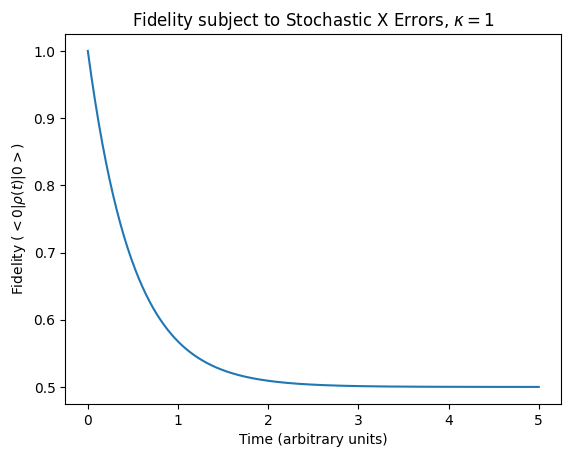

In [5]:
fig, ax = plt.subplots()

ax.plot(T, f_t)
ax.set_ylabel(r"Fidelity ($<0|\rho(t)|0>$)")
ax.set_xlabel(r"Time (arbitrary units)")
ax.set_title(r"Fidelity subject to Stochastic X Errors, $\kappa = 1$");

## (b)
Now suppose we have three qubits and we initialize them in |000⟩. Each of the qubits suffers
from independent stochastic X errors, Jk = σx,k, at the same error rate κk = 1 (for
k = 1, 2, 3). Use QuTiP to simulate the dynamics of the 3-qubit system and plot the fidelity
F (t) = ⟨000| ρ(t) |000⟩ as the qubit evolves

In [6]:
ket_init = qt.tensor([psi0] * 3)
rho_init = ket_init * ket_init.dag()

# 3-qubit identity
I = qt.qeye(2)
I3 = qt.tensor([qt.qeye(2)] * 3)
X = qt.sigmax()

# Create collapse operators
c_1 = qt.tensor([X, I, I])
c_2 = qt.tensor([I, X, I])
c_3 = qt.tensor([I, I, X])

result = qt.mesolve(I3, rho_init, T, c_ops=[c_1, c_2, c_3], e_ops=[rho_init])

f_t = result.expect[0]

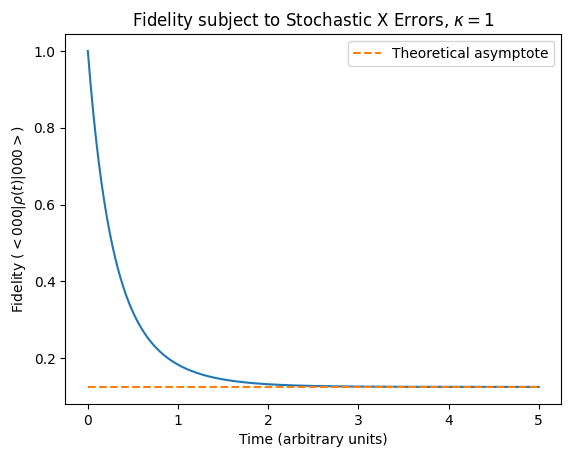

In [7]:
fig, ax = plt.subplots()

ax.plot(T, f_t)
ax.set_ylabel(r"Fidelity ($<000|\rho(t)|000>$)")
ax.set_xlabel(r"Time (arbitrary units)")
ax.set_title(r"Fidelity subject to Stochastic X Errors, $\kappa = 1$");
ax.plot(T, [1/8] * len(T), label='Theoretical asymptote', ls='--')
ax.legend()

## (c)

After an evolution time t, we would like to perform a “stabilizer measurement” by
measuring Z1Z2 and Z2Z3. This allows us to decide in which of the four subspaces the state
is: V0 spanned by {|000⟩ , |111⟩}, V1 spanned by {|100⟩ , |011⟩}, V2 spanned by
{|010⟩ , |101⟩}, or V3 spanned by {|001⟩ , |110⟩}. If you find that the state ends up in Vk
instead of V0, you can perform a σx,k operation on the k-th qubit to return it to V0. This
1
correction operation can be represented as a quantum channel E such that:
ρR(t) = E [ρ(t)] =
3X
j=0
Rj ρ(t)R†
j , (3)
where R0 = |000⟩⟨000| + |111⟩⟨111| and Rj = R0σx,j for j = 1, 2, 3. Plot the fidelity
F (t) = ⟨000| ρR(t) |000⟩ after recovery and compare to the result in (a) and (b). Is it better
or worse for different t? Can you briefly explain the reason?

In [8]:
# Create correction operator

s_111 = qt.tensor([qt.basis(2, 1)] * 3)

R_0 = rho_init + s_111*s_111.dag()

# assemble !
collapse_ops = [c_1, c_2, c_3] # ok since k=1
correctors = [R_0]
for op in collapse_ops:
    correctors.append(R_0 * op)

# Goal here is to test if correction operator
# Works the same after any t step
delta_ts = np.linspace(0, 5, 264)
f_corrected = []
for t in delta_ts:
    T = np.linspace(0, t, 264)
    result = qt.mesolve(I3,
                        rho_init,
                        T,
                        c_ops=collapse_ops
                        )
    # apply correction to final state
    state_final = result.final_state
    state_corrected = np.sum([R * state_final * R.dag() for R in correctors])
    f_corrected.append(qt.expect(rho_init, state_corrected))

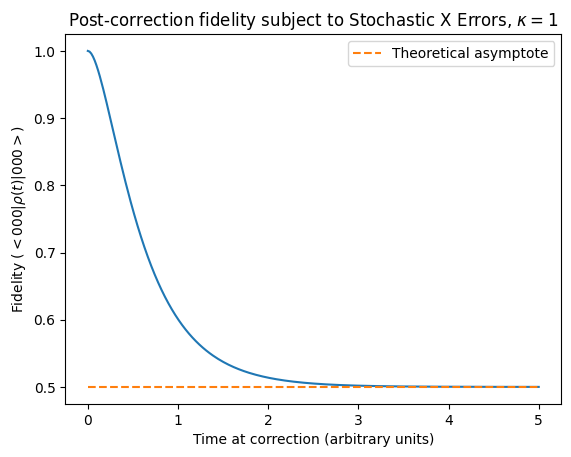

In [9]:
# PLOT
fig, ax = plt.subplots()

ax.plot(delta_ts, f_corrected)
ax.set_ylabel(r"Fidelity ($<000|\rho(t)|000>$)")
ax.set_xlabel(r"Time at correction (arbitrary units)")
ax.set_title(r"Post-correction fidelity subject to Stochastic X Errors, $\kappa = 1$");
ax.plot(T, [0.5] * len(T), label='Theoretical asymptote', ls='--')
ax.legend();

We can see that the decay of fidelity is lessened when using our correction operator--the slope of the decay is initially concave down as opposed to that of the non-corrected expectation value, but still ends up quickly decaying. A significant difference is that the corrected fidelity decays to 0.5 while the uncorrected fidelity decays to 1/8, due to the fact that the correction collapses the state to one of two possible states, while the uncorrected state can be in any of 8 ($2^3$)states due to random bit flips

## (d)

Now we want to perform gate operations. Suppose first we only have one qubit initialized in
|+X⟩ = (|0⟩ + |1⟩) /√2. We want to do a Z gate with the Hamiltonian H = σz . If there is
no noise, after which time ∆t will the state reach |−X⟩ = (|0⟩ − |1⟩)/√2? If during the
evolution, there is a stochastic X error with error rate κ, how does the final fidelity
F = ⟨−X| ρf |−X⟩ change with κ?

/Users/tsol/miniconda3/envs/qproc/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/tsol/miniconda3/envs/qproc/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


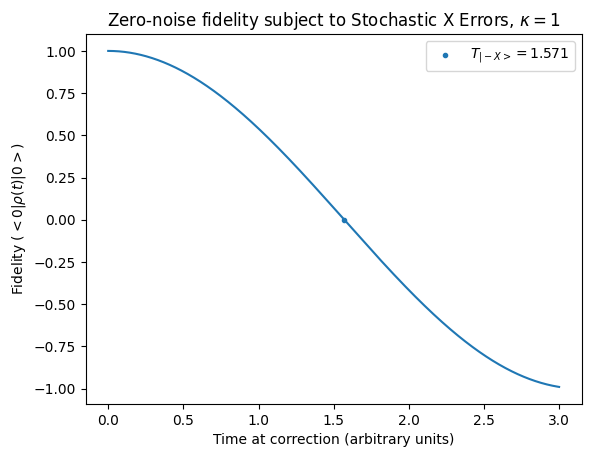

In [10]:
# Initialize ket(+X)
ket_init = 1/np.sqrt(2) * (qt.basis(2, 0) + qt.basis(2, 1))
rho0 = ket_init * ket_init.dag()

T = np.linspace(0, 3, 1000) # High resolution so that we can get accurate time

# Test speed of normal transition, no nosie
result = qt.sesolve(qt.sigmaz(), rho0, T, e_ops=[rho0])
t_f = result.expect[0]

# PLOT
fig, ax = plt.subplots()

ax.plot(T, t_f)
ax.set_ylabel(r"Fidelity ($<0|\rho(t)|0>$)")
ax.set_xlabel(r"Time at correction (arbitrary units)")
ax.set_title(r"Zero-noise fidelity subject to Stochastic X Errors, $\kappa = 1$");
# find minimum
t_min = T[np.argmin(np.abs(t_f))]
ax.scatter(t_min, np.min(np.abs(t_f)), marker='.', label=fr'$T_{{|-X>}}={t_min:.4g}$')
ax.legend();

Thus we see that the normal time for the $Z$ operation to take place is 3.1571=$\frac{\pi}{2}$, which makes sense--we should be making a 1/4 rotation about the Z axis.

In [11]:
# Test final fidelity
kappas = np.linspace(0, 25, 100)

T = np.linspace(0, np.pi/2, 1000)

# Initialize ket(+X)
ket_init = 1/np.sqrt(2) * (qt.basis(2, 0) + qt.basis(2, 1))
rho0 = ket_init * ket_init.dag()

final_expec = []
for kappa in kappas:
    # Set collapse ops (noise channels)
    collapse_ops = [np.sqrt(kappa)*X] # by definition

    # Test speed of normal transition, no noise
    result = qt.mesolve(qt.sigmaz(), rho0, T, c_ops=collapse_ops)

    # Take fidelity value w.r.t. final state
    ket_final = 1/np.sqrt(2) * (qt.basis(2, 0) - qt.basis(2, 1))
    rho_final = ket_final * ket_final.dag()
    final_expec.append(qt.expect(rho_final, result.final_state))

/var/folders/5d/8ff_82ys5wx23f2vrm8f7rw00000gn/T/ipykernel_54176/1411727408.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend();


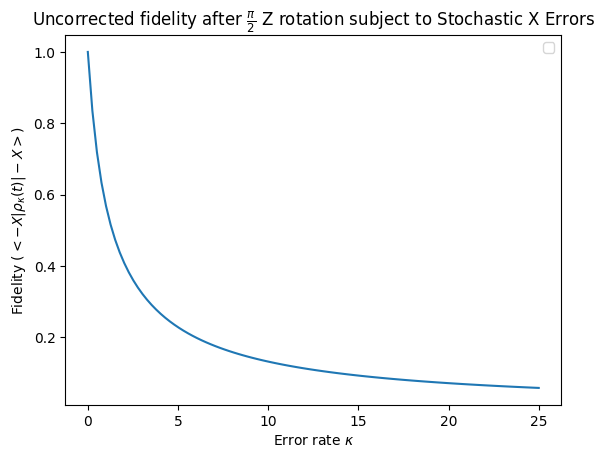

In [12]:
# Graph results
fig, ax = plt.subplots()

ax.plot(kappas, final_expec)
ax.set_ylabel(r"Fidelity ($<-X|\rho_\kappa(t)|-X>$)")
ax.set_xlabel(r"Error rate $\kappa$")
ax.set_title(r"Uncorrected fidelity after $\frac{\pi}{2}$ Z rotation subject to Stochastic X Errors");
ax.legend();

We thus see that the fidelity, if left uncorrected, will asymptotically approach zero as the error rate scales. We see this behavior because at high $\kappa$, the phase becomes more and more evenly "smeared out," increasingly symmetric about the axis orthogonal to that of the |-X> vector. Thus, the fidelity averages out to zero.

## (e)

We now encode one logical qubit in three physical qubits in the following way: |0L⟩ = |000⟩
and |1L⟩ = |111⟩. We initialize the logical qubit in |(+X)L⟩ = (|0L⟩ + |1L⟩)/√2, and use the
Hamiltonian H = (σz,1 + σz,2 + σz,3)/3 for time ∆t to drive the state toward
|(−X)L⟩ = (|0L⟩ − |1L⟩)/√2. However, as in (b), each physical qubit suffers from
independent X errors at the same rate κ. In this case, how does the final fidelity
F = ⟨(−X)L| ρf |(−X)L⟩ change with κ (make a plot in QuTiP)? How does it compare to
the results in (d)? How does this change if we perform the recovery channel described in (c)
for the quantum state ρf we get in the end?

In [13]:
s_000 = qt.tensor([qt.basis(2, 0)] * 3)
s_111 = qt.tensor([qt.basis(2, 1)] * 3)

ket_init = 1/np.sqrt(2) * (s_000 + s_111)
rho_init = ket_init * ket_init.dag()

ket_final = 1/np.sqrt(2) * (s_000 - s_111)
rho_final = ket_final * ket_final.dag()

Z = qt.sigmaz()
# Assemble Hamiltonian
H = 1/3 * (qt.tensor(Z, I, I) + qt.tensor(I, Z, I) + qt.tensor(I, I, Z))

# Create three-channel independent decay
decay = lambda kappa: [
    np.sqrt(kappa) * qt.tensor(X, I, I),
    np.sqrt(kappa) * qt.tensor(I, X, I),
    np.sqrt(kappa) * qt.tensor(I, I, X),
]

T = np.linspace(0, 3*np.pi/2, 500) # evolve for three times as long to offset hamiltonian

fidelities = []
f_state = []
for kappa in kappas:
    result = qt.mesolve(H, rho_init, T, c_ops=decay(kappa))
    f_state.append(result.final_state)
    fidelities.append(qt.expect(rho_final, result.final_state))

# Now try error correcting the final state
error_corrected_results = []
for state_final in f_state:
    state_corrected = np.sum([R * state_final * R.dag() for R in correctors])
    error_corrected_results.append(qt.expect(rho_final, state_corrected))


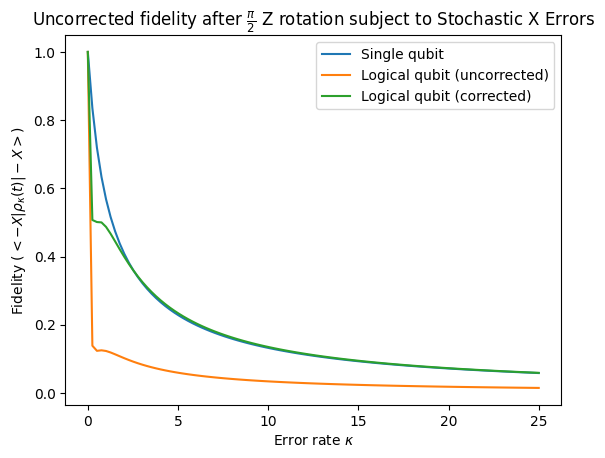

In [14]:
# Plot
# Graph results
fig, ax = plt.subplots()

ax.plot(kappas, final_expec, label='Single qubit')
ax.plot(kappas, fidelities, label='Logical qubit (uncorrected)')
ax.plot(kappas, error_corrected_results, label='Logical qubit (corrected)')
ax.set_ylabel(r"Fidelity ($<-X|\rho_\kappa(t)|-X>$)")
ax.set_xlabel(r"Error rate $\kappa$")
ax.set_title(r"Uncorrected fidelity after $\frac{\pi}{2}$ Z rotation subject to Stochastic X Errors");
ax.legend();

That first region looks pretty interesting--let's zoom in

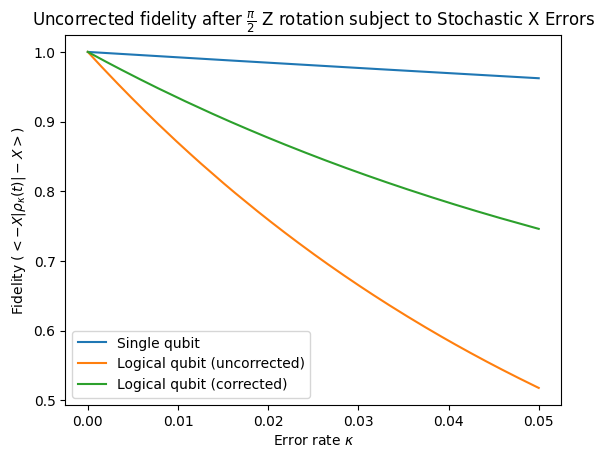

In [15]:
s_000 = qt.tensor([qt.basis(2, 0)] * 3)
s_111 = qt.tensor([qt.basis(2, 1)] * 3)

ket_init = 1/np.sqrt(2) * (s_000 + s_111)
rho_init = ket_init * ket_init.dag()

ket_final = 1/np.sqrt(2) * (s_000 - s_111)
rho_final = ket_final * ket_final.dag()

T = np.linspace(0, 3*np.pi/2, 500)
small_kappas = np.linspace(0, 0.05, 200)
fidelities = []
f_state = []
for kappa in small_kappas:
    result = qt.mesolve(H, rho_init, T, c_ops=decay(kappa))
    f_state.append(result.final_state)
    fidelities.append(qt.expect(rho_final, result.final_state))

# Now try error correcting the final state
error_corrected_results = []
for state_final in f_state:
    state_corrected = np.sum([R * state_final * R.dag() for R in correctors])
    error_corrected_results.append(qt.expect(rho_final, state_corrected))

T = np.linspace(0, np.pi/2, 500)
# Recalculate values from (d) with new kappa range
original_expec = []
for kappa in small_kappas:
    # Set collapse ops (noise channels)
    collapse_ops = [np.sqrt(kappa)*X] # by definition
    ket_init_u = 1/np.sqrt(2) * (qt.basis(2, 0) + qt.basis(2, 1))
    rho_init_u = ket_init_u * ket_init_u.dag()
    # Test speed of normal transition, no noise
    result = qt.mesolve(qt.sigmaz(), rho_init_u, T, c_ops=collapse_ops)

    # Take fidelity value w.r.t. final state
    ket_final_u = 1/np.sqrt(2) * (qt.basis(2, 0) - qt.basis(2, 1))
    rho_final_u = ket_final_u * ket_final_u.dag()
    original_expec.append(qt.expect(rho_final_u, result.final_state))

# Plot
# Graph results
fig, ax = plt.subplots()

ax.plot(small_kappas, original_expec, label='Single qubit')
ax.plot(small_kappas, fidelities, label='Logical qubit (uncorrected)')
ax.plot(small_kappas, error_corrected_results, label='Logical qubit (corrected)')
ax.set_ylabel(r"Fidelity ($<-X|\rho_\kappa(t)|-X>$)")
ax.set_xlabel(r"Error rate $\kappa$")
ax.set_title(r"Uncorrected fidelity after $\frac{\pi}{2}$ Z rotation subject to Stochastic X Errors");
ax.legend();

Thus we can see that using error correction, the logical qubit's performance bridges the gap between the uncorrected result and the single qubit result.

# Problem 3-2


## (a)

### (i)
- R must be positive, to push electrons into the 2DEG phase and form a "pool"
- G1 and G2 should most likely both be negative to gate in electrons from jumping straight to the reservoir
- G3 should be just slightly negative to create the tunnling barrier over the prongs of R, which will protrude into G1 and G2, lessening their barrier
- C should be strongly negative to confine the q-dot in the other three xy directions (left right and bottom in this diagram)

### (ii)
G4 is the chemical potential of the dot. By tuning the voltage of G4, we can raise or lower the potential at the dot (but the voltage of G4 should be overall positive)

### (iii)
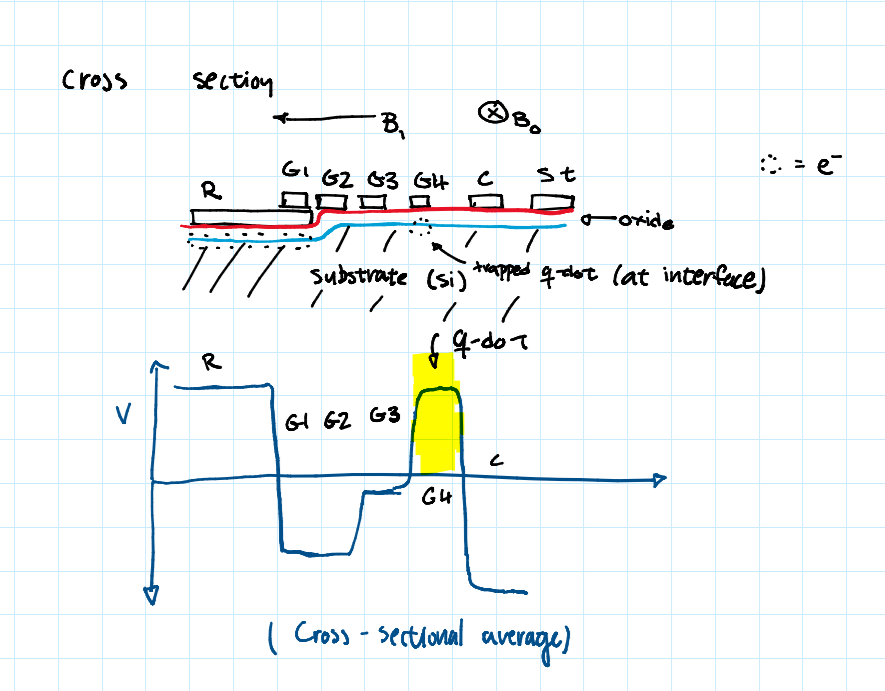

### (iv)
The potential of the G3 gate.

### (v)
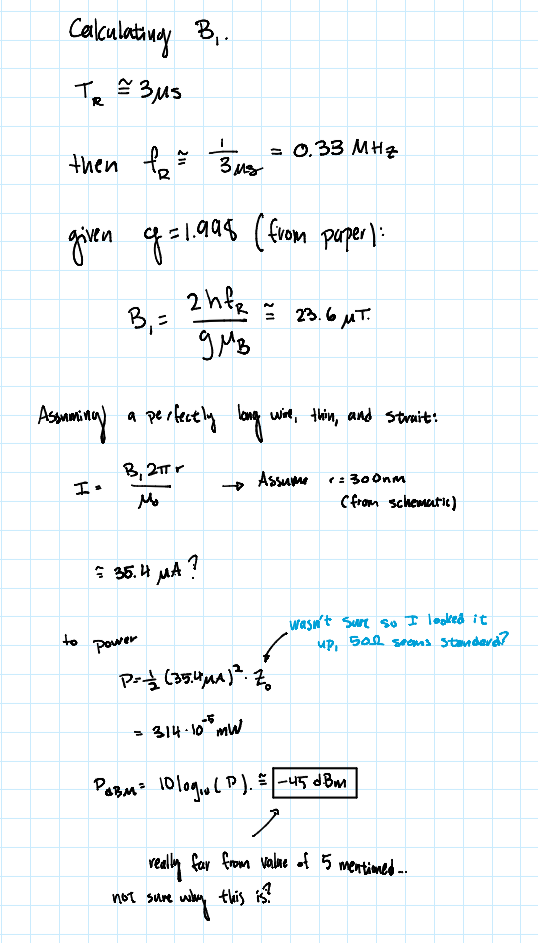

### (vi)
Volume = 40 nm * 40 nm * 20 nm = 32,000 nm^3

then total atoms in dot would be on order of
Density of Silicon = ~50 atoms/nm^3
Total Atoms = 32,000 nm^3 * 50 atoms/nm^3 = 1,600,000 atoms

Only the 29-Si isotope has a nuclear spin. The paper uses purified silicon with an 800 ppm (0.0008) concentration of 29-Si.
Silicon Spins = 1,600,000 atoms * 0.0008 = 1,280 spins

In Gallium Arsenide, 100% of the atoms have a nuclear spin.
GaAs Spins = 1,600,000 atoms * 1 = 1,600,000 spins

The electron in the purified silicon dot interacts with only ~1,280 nuclear spins, compared to ~1.6 million spins in an identical GaAs dot. This emmense difference is why silicon has a such a large advantage over a GaAs dot!

## (b)
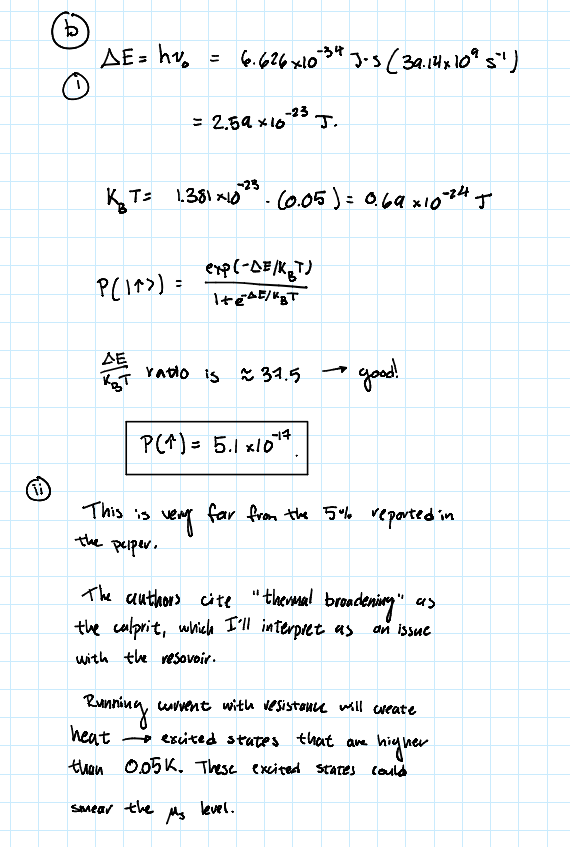

## (c)
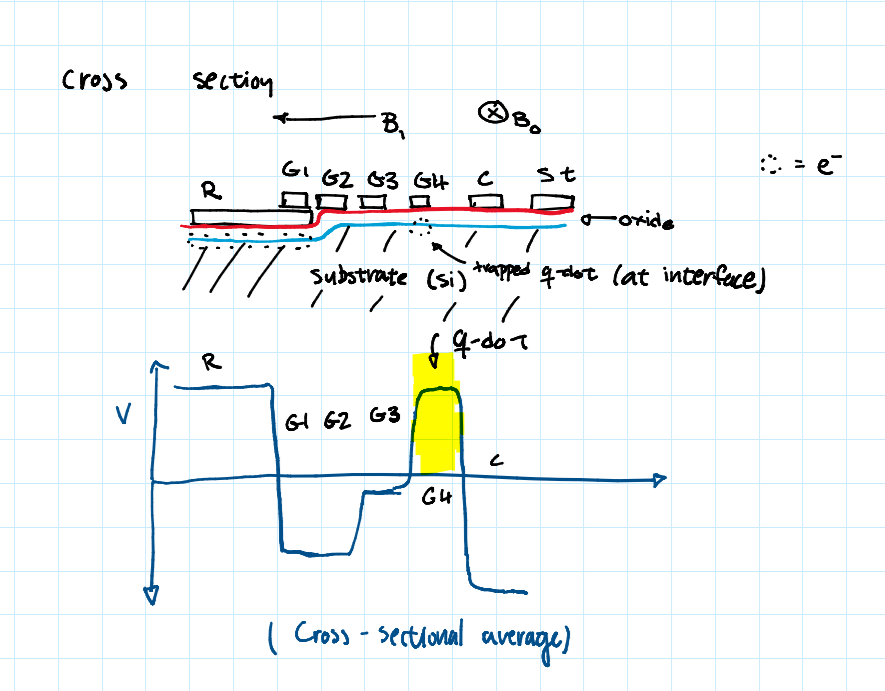

## (d)

In [ ]:
f_rabi = 0.292  # MHz (calculated from tau_p = 8.56 us peak)
omega = 2 * np.pi * f_rabi # Angular Rabi frequency

# Time and detuning arrays from Figure 2d
T = np.linspace(0, 30, 200)
detunings_MHz = np.linspace(-1.0, 1.0, 100) # Detuning in MHz
detunings = 2 * np.pi * detunings_MHz # angular frequency

# Initialize in spin-down state
psi_init = qt.basis(2, 1)
P_up = qt.basis(2, 0) * qt.basis(2, 0).dag() # Measure spin-up tho

# Simulate the ideal scenario
output_ideal = np.zeros((len(detunings), len(T)))
visibility = 0.7 # scaling factor A from paper

# Sweep over each detuned frequency and generate sine wave
for i, delta in enumerate(detunings):
    # Hamiltonian in the rotating frame
    H = 0.5 * delta * Z + 0.5 * omega * X
    # Solve standard unitary evolution
    result = qt.mesolve(H, psi_init, T, [], [P_up])
    output_ideal[i, :] = visibility * result.expect[0]

# Base T2* was 120 us, we want 10x
T2_fast = 12.0 
gamma_phi = 1.0 / T2_fast

# Collapse operator for pure dephasing
c_ops = [np.sqrt(gamma_phi / 2.0) * Z]
out_dephased = np.zeros((len(detunings), len(T)))

for i, delta in enumerate(detunings):
    H = 0.5 * delta * Z + 0.5 * omega * X
    # mesolve now uses the Lindblad master equation due to c_ops
    result = qt.mesolve(H, psi_init, T, c_ops, [P_up])
    out_dephased[i, :] = visibility * result.expect[0]

/Users/tsol/miniconda3/envs/qproc/lib/python3.11/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


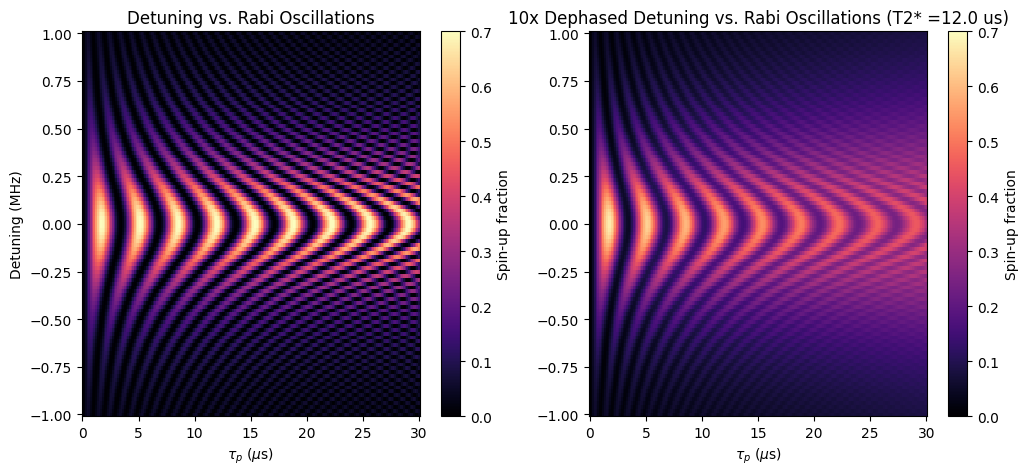

In [17]:
# PLOT
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Ideal
c1 = ax1.pcolormesh(T, detunings_MHz, output_ideal, cmap='magma', shading='auto', vmin=0, vmax=visibility)
ax1.set_title('Detuning vs. Rabi Oscillations')
ax1.set_xlabel(r'$\tau_p$ ($\mu$s)')
ax1.set_ylabel('Detuning (MHz)')

# Plot Dephased
c2 = ax2.pcolormesh(T, detunings_MHz, out_dephased, cmap='magma', shading='auto', vmin=0, vmax=visibility)
ax2.set_title(f'10x Dephased Detuning vs. Rabi Oscillations (T2* ={T2_fast} us)')
ax2.set_xlabel(r'$\tau_p$ ($\mu$s)')

plt.colorbar(c1, ax=ax1, label='Spin-up fraction')
plt.colorbar(c2, ax=ax2, label='Spin-up fraction');

## (e)

Just like in NMR, the oscillation frequency is determined by the detuning.

In [ ]:
detuning_MHz = 0.05  # 50 kHz detuning to generate visible fringes
delta = 2 * np.pi * detuning_MHz
T = np.linspace(0, 120, 200) # Wait times up to 120 us

P_up = qt.basis(2, 0) * qt.basis(2, 0).dag()

# pi/2 pulse -- defining as an explicit operation bc we
# can approximate it as instintaneous and also has an easy form
pi_2_pulse = (-1j * (np.pi/4) * X).expm()

psi_init = qt.basis(2, 1)
psi_after_pulse1 = pi_2_pulse * psi_init

# Free evolution
H_free_res = 0.0 * Z # Resonant 
H_free_det = 0.5 * delta * Z # Detuned

result_res_ideal = qt.sesolve(H_free_res, psi_after_pulse1, T)
result_det_ideal = qt.sesolve(H_free_det, psi_after_pulse1, T)

# I'm also gonna approximate the second pi/2 pulse as being instentaneous
# Shows the the oscillation that we needed
expect_res_ideal = []
expect_det_ideal = []

for state in result_res_ideal.states:
    final_state = pi_2_pulse * state
    expect_res_ideal.append(qt.expect(P_up, final_state))

for state in result_det_ideal.states:
    final_state = pi_2_pulse * state
    expect_det_ideal.append(qt.expect(P_up, final_state))

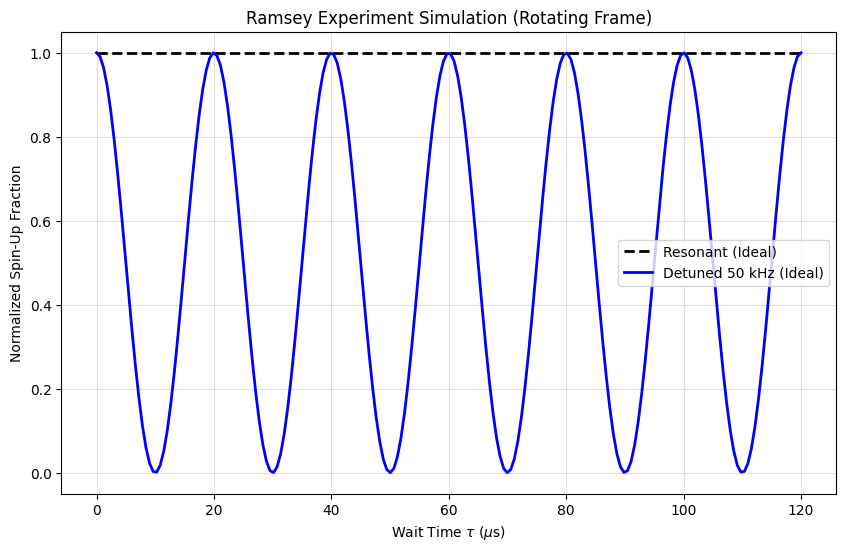

In [24]:
plt.figure(figsize=(10, 6))

plt.plot(T, expect_res_ideal, label='Resonant (Ideal)', ls='--', color='black', linewidth=2)
plt.plot(T, expect_det_ideal, label=f'Detuned {detuning_MHz*1000:.0f} kHz (Ideal)', color='blue', linewidth=2)

plt.title('Ramsey Experiment Simulation (Rotating Frame)')
plt.xlabel(r'Wait Time $\tau$ ($\mu$s)')
plt.ylabel('Normalized Spin-Up Fraction')
plt.legend(loc='best')
plt.grid(True, alpha=0.4)

### (ii)

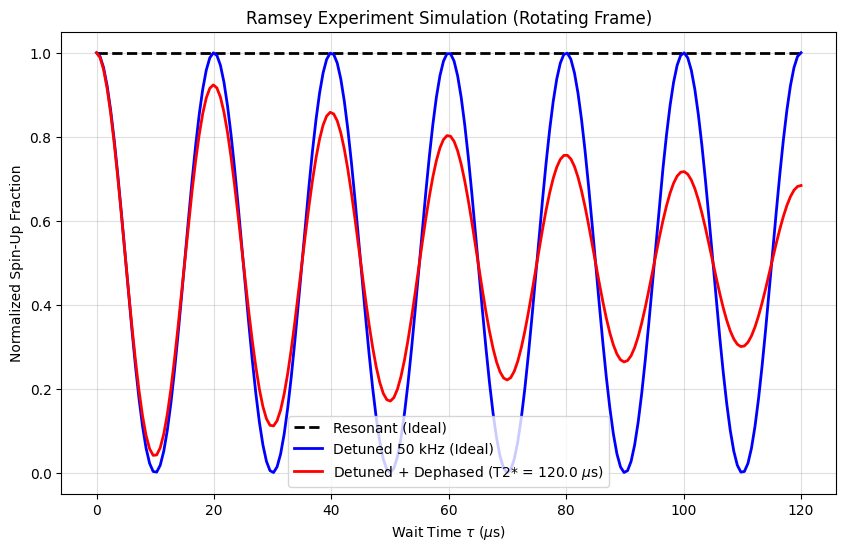

In [25]:
T2_star = 120.0 # us (From Fig 3a in the paper)
gamma_phi = 1.0 / T2_star

c_ops = [np.sqrt(gamma_phi / 2.0) * Z]

result_det_dephased = qt.mesolve(H_free_det, psi_after_pulse1, T, c_ops=c_ops)

expect_det_dephased = []

# Again considering instintaneous pulses... difference would be very minor
for rho in result_det_dephased.states:
    final_rho = pi_2_pulse * rho * pi_2_pulse.dag()
    expect_det_dephased.append(qt.expect(P_up, final_rho))

# PLOT
plt.figure(figsize=(10, 6))

plt.plot(T, expect_res_ideal, label='Resonant (Ideal)', ls='--', color='black', linewidth=2)
plt.plot(T, expect_det_ideal, label=f'Detuned {detuning_MHz*1000:.0f} kHz (Ideal)', color='blue', linewidth=2)
plt.plot(T, expect_det_dephased, label=f'Detuned + Dephased (T2* = {T2_star} $\mu$s)', color='red', linewidth=2)

plt.title('Ramsey Experiment Simulation (Rotating Frame)')
plt.xlabel(r'Wait Time $\tau$ ($\mu$s)')
plt.ylabel('Normalized Spin-Up Fraction')
plt.legend(loc='best')
plt.grid(True, alpha=0.4)
plt.show()

### (iii)

In 3b, only a single pi pulse is used halfway through the waiting period, which kills very slow changing dephasing but can't affect any faster moving changes, which will dephase unpredictibly. By shortening the time between pulses as in c, we can eliminate the quick changes in dephasing and keep the phase in the right "neighborhood" for longer.